In [13]:
from rasterio.windows import Window
import numpy as np
import json
import os
from pathlib import Path
import random
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import glob
import geopandas as gpd
import re
from shapely.geometry import box, mapping
from rasterio.transform import Affine
from rasterio import features
from shapely.affinity import affine_transform
from PIL import Image 
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
## import the function
from src.utils.util import load_config, load_json
from src.utils.utilstiles import map_path_to_tile_info, create_metadata_patches
from src.utils.bitmap import create_binary_mask, generate_bitmaps, save_bitmap
from src.utils.plots import plot_images

In [2]:
from src.utils import util
importlib.reload(util)

<module 'src.utils.util' from '/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dev/src/utils/util.py'>

## Config File

### Read the config file. 

The config file stores all the paths for the project.

In [3]:
## load config
print(os.getcwd())
config = load_config(config_path="./src/config/config.yaml")
print(config)

/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dev
{'datasets': {'root_folder': '/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset', 'name_tile_folder': 'tiles', 'name_metadata_folder': 'tiles_metadata', 'name_bitmap_folder': 'bitmap', 'name_labels_folder': 'labels', 'name_labels_segmentation': 'labels_segmentation', 'grid_tiles_json': '/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/tiles.json', 'building_shp': '/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/shp'}}


## Patching the whole COG using Cog2tiles function

For create the patch, the cog2tile is used. 

Warning: This function uses the grid provided by Mercantile, however do not have option for overlapping tiles. 

Change the name of the input.tif to the desired COG file. 
```
cog2tiles input.tif -z 19 --tile-size 512 --extension png --output-dir tiles/ --workers 64
```

### Visualize generated patches

- All the paths are stored in the config path. see at: /config/config.yaml

In [4]:
## retrieve a list with all files 
list_files =  glob.glob(os.path.join(config["datasets"]["root_folder"], 
                                    config["datasets"]["name_tile_folder"], 
                                                                    '*.tif'
                                    )
                        )
                       
print("Path names of the tiles:")
print('\n'.join(list_files[:2])) 


Path names of the tiles:
/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199122-295996-19.tif
/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199120-295975-19.tif


tile-199117-295985-19.tif


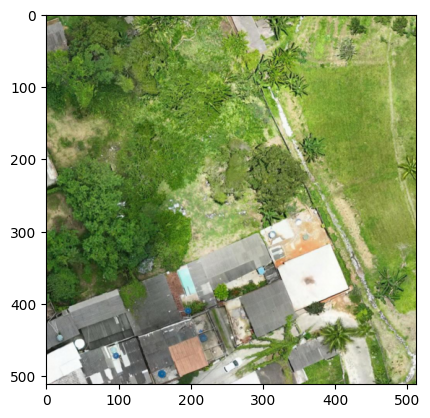

In [13]:
## show random image from list of paths
img_path = random.sample(list_files,1)[0]
img = cv2.imread(img_path)
print(img_path.split('/')[-1])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #convert BGR to RGB
plt.imshow(img)


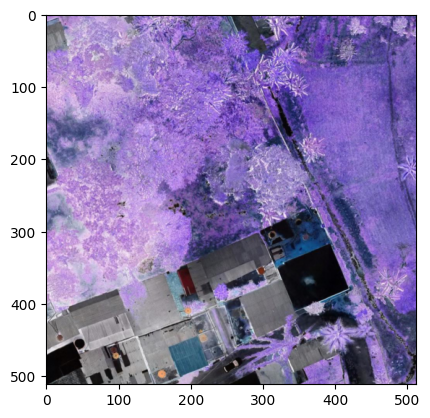

In [14]:
from skimage.util import invert
invert = invert(img)
plt.imshow(invert)

## Creating Metadata for patches of Building Footprint

Using mercantile and cog2tiles. 

Mercantile gives the same patches as the given by cog2tiles. 
The following function will add metadata into each patch created at.

In [183]:
## PATH of the metadata json containing the grids.
geojson_mercantile_path = config["datasets"]["grid_tiles_json"]

## read as geopandas
gdf = gpd.read_file(geojson_mercantile_path)

## add columns
gdf['x_tile'] = gdf['id'].apply(lambda obj : int(re.findall( "[0-9].*", obj.split(',')[0])[0]))
gdf['y_tile'] = gdf['id'].apply(lambda obj : int(re.findall( "[0-9].*", obj.split(',')[1])[0]))
gdf['z_tile'] = gdf['id'].apply(lambda obj : int(re.findall( "[0-9].", obj.split(',')[2])[0]))

In [184]:
gdf.head()

,id,title,geometry,x_tile,y_tile,z_tile
0,"(199101, 295964, 19)","XYZ tile (199101, 295964, 19)","POLYGON ((-43.28819 -22.61211, -43.28819 -22.6...",199101,295964,19
1,"(199102, 295964, 19)","XYZ tile (199102, 295964, 19)","POLYGON ((-43.28751 -22.61211, -43.28751 -22.6...",199102,295964,19
2,"(199103, 295964, 19)","XYZ tile (199103, 295964, 19)","POLYGON ((-43.28682 -22.61211, -43.28682 -22.6...",199103,295964,19
3,"(199104, 295964, 19)","XYZ tile (199104, 295964, 19)","POLYGON ((-43.28613 -22.61211, -43.28613 -22.6...",199104,295964,19
4,"(199105, 295964, 19)","XYZ tile (199105, 295964, 19)","POLYGON ((-43.28545 -22.61211, -43.28545 -22.6...",199105,295964,19


In [185]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Create metadata

It creates the metadata by looking at each image and adding relevant metadata from the grid metadata. So each image stores relevant information in a json file with the same name as the input image, however, stored in another folder.

In [186]:
output_dir = config["datasets"]["root_folder"] + '/' + config["datasets"]["name_metadata_folder"]

## See function for a better understandment 
create_metadata_patches(gdf,
                         list_files, # this list was created above with the tiles folder
                           output_dir)

Reading tile: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199122-295996-19.tif
Metadata saved to tile-199122-295996-19.json
Reading tile: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199120-295975-19.tif
Metadata saved to tile-199120-295975-19.json
Reading tile: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199119-295998-19.tif
Metadata saved to tile-199119-295998-19.json
Reading tile: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199119-295999-19.tif
Metadata saved to tile-199119-295999-19.json
Reading tile: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199119-295977-19.tif
Metadata saved to tile-199119-295977-19.json
Reading tile: /home/camarada/Documents/CDE/3-semester/DeepLe

In [187]:
## load a single metadata to see it
list_metadata = glob.glob(os.path.join(config["datasets"]["root_folder"], config["datasets"]["name_metadata_folder"],"*.json"))
    
load_json(list_metadata[1])

{'patch_id': '(199115, 295989, 19)',
 'x_tile': 199115,
 'y_tile': 295989,
 'z_tile': 19,
 'filename': 'tile-199115-295989-19',
 'crs': 'EPSG:4326',
 'geometry': 'POLYGON ((-43.27857971191406 -22.62795494665143, -43.27857971191406 -22.627321155863363, -43.27789306640625 -22.627321155863363, -43.27789306640625 -22.62795494665143, -43.27857971191406 -22.62795494665143))',
 'max_gray_value': 253,
 'min_gray_value': 5,
 'max_min_diff': 248,
 'percentage_white': 0.0053,
 'percentage_black': 0.0001,
 'sum_black_white': 0.0054}

## Bitmap - Building Footprint

In [22]:
from src.utils import utilstiles
from src.utils.utilstiles import find_tile_per_x_y_z, add_folder_to_path_name

In [24]:
from src.utils.plots import print_img, plot_images, plot_pairwise_simple, plot_pairwise

In [27]:
## get footprint shapefile inside the folders
for dirpath, dirs, files in os.walk(config["datasets"]["building_shp"]): 
  for filename in files:
    fname = os.path.join(dirpath,filename)
    if fname.endswith('.shp'):
      print(fname)

/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/data/shp/building-footprint.shp


In [30]:
## load buildings footprint shp
buildings = gpd.read_file(fname)
buildings["id"] = buildings.index

##CONVERT 4326
buildings4326 = buildings.to_crs("EPSG:4326")

print("shape gdf:",buildings4326.shape)
print(f"There are {buildings4326.shape[0]} buildings in the shapefile.")

shape gdf: (504, 2)
There are 504 buildings in the shapefile.


In [ ]:

## Folder path name 
folder_tile_path = os.path.join(config["datasets"]["root_folder"], config["datasets"]["name_tile_folder"])
print("Folder tile name:",folder_tile_path) ## name of the folder with the drone tiles.

## add path to gdf
gdf["path_name"]=gdf.apply(lambda row:find_tile_per_x_y_z(row["x_tile"],
                                                          row["y_tile"],
                                                          row["z_tile"]),axis=1)
gdf["full_path"] = gdf.apply(lambda row: add_folder_to_path_name(row["path_name"],
                                                                 folder_tile_path),
                                                                axis=1)

print(gdf.shape)
print(gdf.columns)

Folder tile name: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/data/improved_dataset/tiles
(851, 8)
Index(['id', 'title', 'geometry', 'x_tile', 'y_tile', 'z_tile', 'path_name',
       'full_path'],
      dtype='object')


### Spatial Intersection of Grid tiles and each patches

Create a spatial join between the shapefile with the rooftops arbitrary choosen and the gdf of the patches (tiles) created from the full drone image. 

In [38]:
## create the spatial join gdf that will hold the whole operation downstream
intersection = buildings4326.sjoin(gdf, how='left', predicate="intersects", lsuffix="buildings",rsuffix="tile")

print(intersection.shape)
intersection.head()

(695, 10)


,id_buildings,geometry,index_tile,id_tile,title,x_tile,y_tile,z_tile,path_name,full_path
0,0,"POLYGON ((-43.28463 -22.6179, -43.28453 -22.61...",235,"(199106, 295974, 19)","XYZ tile (199106, 295974, 19)",199106,295974,19,tile-199106-295974-19.tif,/home/camarada/Documents/CDE/3-semester/DeepLe...
1,1,"POLYGON ((-43.28491 -22.61576, -43.28484 -22.6...",142,"(199105, 295970, 19)","XYZ tile (199105, 295970, 19)",199105,295970,19,tile-199105-295970-19.tif,/home/camarada/Documents/CDE/3-semester/DeepLe...
2,2,"POLYGON ((-43.28459 -22.61576, -43.28448 -22.6...",143,"(199106, 295970, 19)","XYZ tile (199106, 295970, 19)",199106,295970,19,tile-199106-295970-19.tif,/home/camarada/Documents/CDE/3-semester/DeepLe...
3,3,"POLYGON ((-43.28379 -22.61615, -43.2837 -22.61...",167,"(199107, 295971, 19)","XYZ tile (199107, 295971, 19)",199107,295971,19,tile-199107-295971-19.tif,/home/camarada/Documents/CDE/3-semester/DeepLe...
4,4,"POLYGON ((-43.28371 -22.61646, -43.28366 -22.6...",167,"(199107, 295971, 19)","XYZ tile (199107, 295971, 19)",199107,295971,19,tile-199107-295971-19.tif,/home/camarada/Documents/CDE/3-semester/DeepLe...


## BitMap

In [39]:
from src.utils.bitmap import generate_bitmaps

In [40]:
folder_bitmap_path = config["datasets"]["root_folder"] + '/' + config["datasets"]["name_bitmap_folder"]

## generate the bitmap
generate_bitmaps(intersection,
                             gdf,
                             folder_bitmap_path,
                             save_format="png")

Processing Intersection 27 (0/181)
  ✓ Saved: tile-199105-295965-19.png
Processing Intersection 30 (1/181)
  ✓ Saved: tile-199108-295965-19.png
Processing Intersection 31 (2/181)
  ✓ Saved: tile-199109-295965-19.png
Processing Intersection 49 (3/181)
  ✓ Saved: tile-199104-295966-19.png
Processing Intersection 50 (4/181)
  ✓ Saved: tile-199105-295966-19.png
Processing Intersection 52 (5/181)
  ✓ Saved: tile-199107-295966-19.png
Processing Intersection 53 (6/181)
  ✓ Saved: tile-199108-295966-19.png
Processing Intersection 71 (7/181)
  ✓ Saved: tile-199103-295967-19.png
Processing Intersection 72 (8/181)
  ✓ Saved: tile-199104-295967-19.png
Processing Intersection 73 (9/181)
  ✓ Saved: tile-199105-295967-19.png
Processing Intersection 74 (10/181)
  ✓ Saved: tile-199106-295967-19.png
Processing Intersection 75 (11/181)
  ✓ Saved: tile-199107-295967-19.png
Processing Intersection 76 (12/181)
  ✓ Saved: tile-199108-295967-19.png
Processing Intersection 77 (13/181)
  ✓ Saved: tile-199109-29

{'success': [27,
  30,
  31,
  49,
  50,
  52,
  53,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  94,
  96,
  97,
  98,
  99,
  100,
  101,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  164,
  165,
  167,
  168,
  169,
  170,
  171,
  190,
  191,
  192,
  193,
  209,
  211,
  212,
  213,
  214,
  215,
  216,
  232,
  233,
  235,
  236,
  237,
  238,
  239,
  259,
  260,
  261,
  282,
  283,
  301,
  302,
  303,
  305,
  324,
  325,
  326,
  327,
  328,
  329,
  330,
  348,
  349,
  350,
  351,
  352,
  353,
  354,
  371,
  372,
  373,
  374,
  375,
  393,
  394,
  395,
  396,
  397,
  398,
  399,
  417,
  418,
  419,
  420,
  421,
  439,
  440,
  441,
  442,
  491,
  492,
  493,
  494,
  513,
  514,
  515,
  516,
  517,
  518,
  536,
  537,
  538,
  539,
  540,
  541,
  557,
  558,
  559,
  560,
  561,
  580,
  581,
  582,
  583,
  586,
  587,
  605,
  606,
  607,
  608,
  609,
  610,
  611,
  612,
  630,
 

### Visualize Bitmap

In [6]:
list_bitmap = glob.glob(os.path.join(
    config["datasets"]["root_folder"],
    config["datasets"]["name_bitmap_folder"],
    "*.png"
))

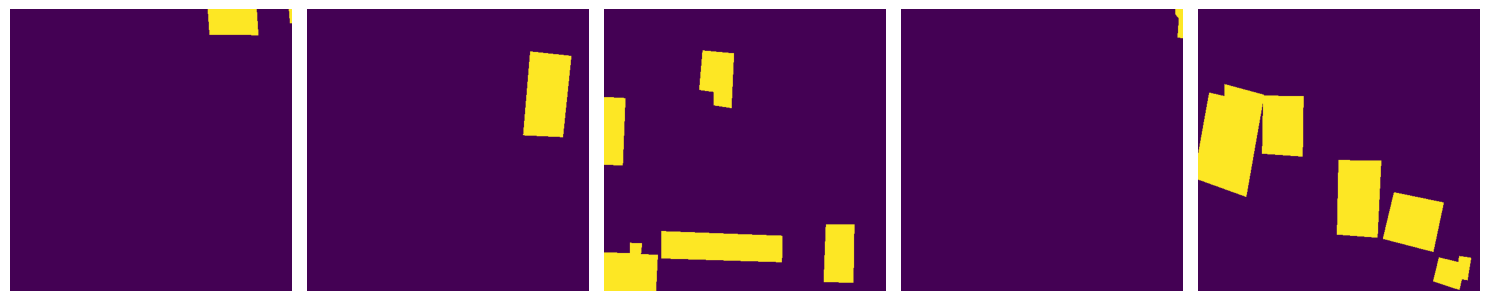

In [7]:
import random

## plot to see the results
plot_images(random.sample(list_bitmap,5))

### Pairwise plot 

In [8]:
from src.utils.plots import plot_pairwise

## plot the pairwise 
# Create lookup dictionary
bitmap_dict = {Path(f).stem: f for f in list_bitmap}

# Find matches
matching_pairs = [(tile, bitmap_dict[Path(tile).stem]) 
                  for tile in list_files 
                  if Path(tile).stem in bitmap_dict]

Plotting 8 pairs in 4 rows x 2 pairs per row


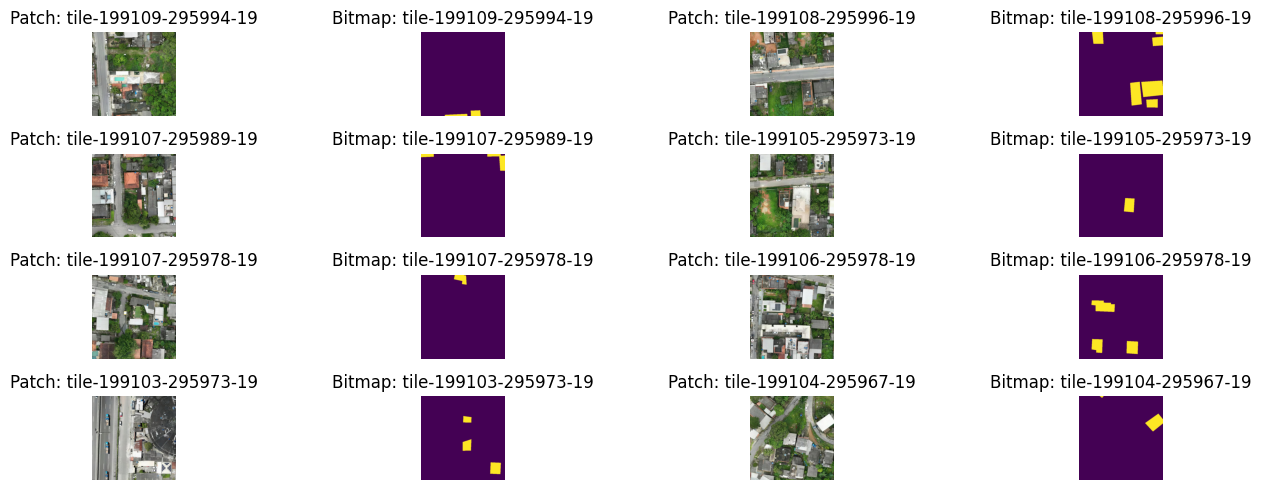

In [194]:
plot_pairwise(random.sample(matching_pairs, 8))

### Singular Image Check

In [10]:
random_img = random.randint(0, len(matching_pairs) - 1)

## show
imgg= cv2.imread(matching_pairs[random_img][0], ##RANDOM IMAGE
                 cv2.IMREAD_COLOR_RGB)

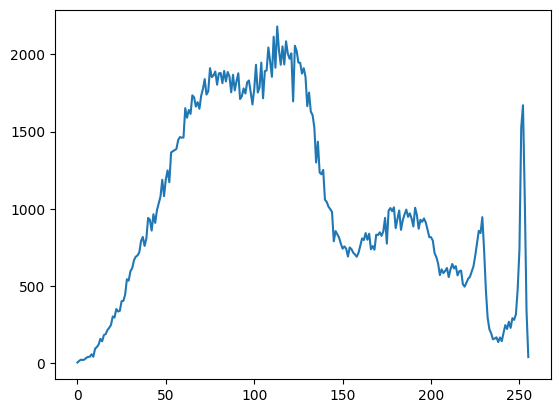

In [11]:
gray = rgb2gray(imgg)
counts, _= np.histogram(gray.flatten(),256)
plt.plot(counts)

Plotting 1 pairs in 1 rows x 2 pairs per row


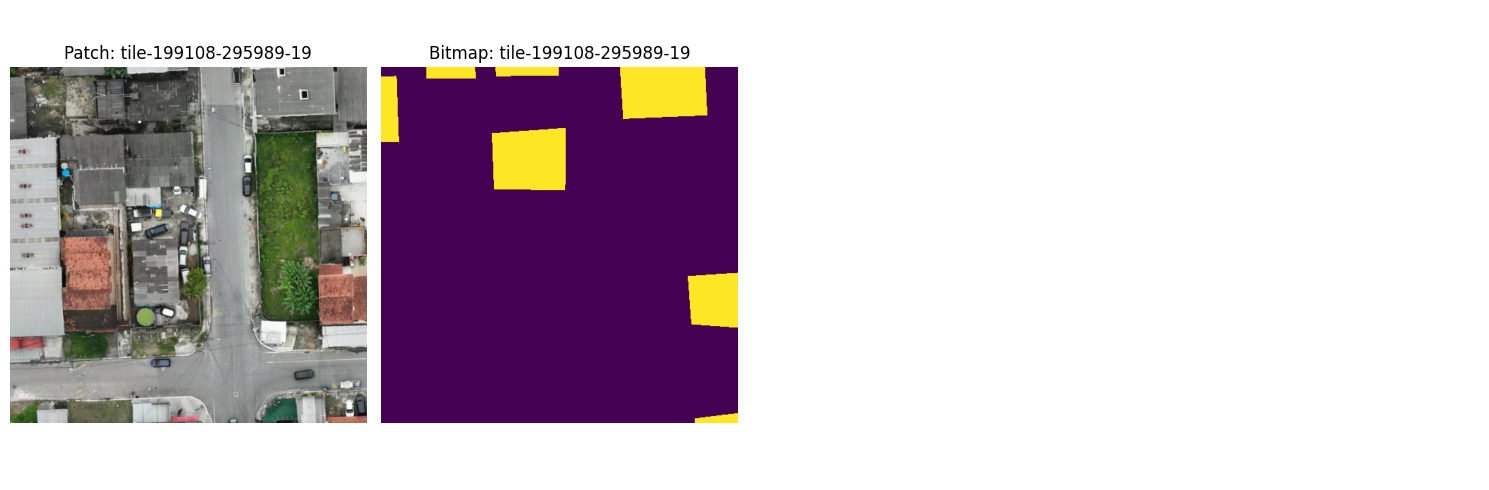

In [98]:
plot_pairwise(matching_pairs[random_img:],1)

## Creating Labels for Yolo models

### Singular image - exploring

In [ ]:
from src.utils.labelling import get_classification_bbox

In [21]:
## read the bitmap as a grayscale image
imgg = cv2.imread(matching_pairs[random_img][1],
                   cv2.IMREAD_GRAYSCALE
                   )

## need to rescale the image to 0-255 instead of 0-1 
imgg_ = imgg*255

## threshold
_, thresh = cv2.threshold(imgg_, 127, 255, 0)

## contour
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# (height, width)
img_h, img_w = imgg.shape 

for cnt in contours:
    if cv2.contourArea(cnt) < 10: continue

    # Get Centroid via Moments
    M = cv2.moments(cnt)
    if M["m00"] == 0: continue
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])

    # Get original w, h from standard bounding box
    _, _, w, h = cv2.boundingRect(cnt)

    # Create a Square BBox (aspect_ratio=1.0) with 20% padding
    x1, y1, x2, y2 = get_classification_bbox((cX, cY), w, h, padding=0.2, aspect_ratio=1.0)

    # CLIPPING: Ensure box stays within image boundaries
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)

    # Crop for classification
    crop = imgg[y1:y2, x1:x2]
    
    print(f"Original Centroid: {cX}, {cY} | New BBox: [{x1}, {y1}, {x2}, {y2}]")

Original Centroid: 498, 504 | New BBox: [481, 487, 512, 512]
Original Centroid: 423, 462 | New BBox: [373, 412, 472, 511]
Original Centroid: 356, 467 | New BBox: [303, 414, 408, 512]
Original Centroid: 231, 438 | New BBox: [151, 358, 310, 512]
Original Centroid: 2, 391 | New BBox: [0, 327, 65, 454]
Original Centroid: 126, 416 | New BBox: [60, 350, 192, 482]
Original Centroid: 398, 309 | New BBox: [320, 231, 476, 387]
Original Centroid: 178, 221 | New BBox: [118, 161, 237, 280]
Original Centroid: 420, 157 | New BBox: [371, 108, 468, 205]
Original Centroid: 67, 110 | New BBox: [14, 57, 119, 162]
Original Centroid: 65, 15 | New BBox: [38, 0, 91, 41]


In [ ]:
## read the bitmap as a grayscale image
imgg = cv2.imread(matching_pairs[random_img][1],
                   cv2.IMREAD_GRAYSCALE
                   )

## need to rescale the image to 0-255 instead of 0-1 
imgg_ = imgg*255

## get vars
imgg_height, imgg_width = imgg.shape

## threshold
_, thresh = cv2.threshold(imgg_, 127, 255, 0)

## contour
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Process each contour
for cnt in contours:
    # Skip very small contours (noise)
    if cv2.contourArea(cnt) < 10:
        print(f"WARNING: Area of contour is lesser than threshold!")
        continue
    
    # Get bounding box
    x, y, w, h = cv2.boundingRect(cnt)

    # (normalized coordinates) 
    print(f"Bbox of normalized points: x_center, y_center, height, width") 
    x_center, y_center, w_, h_ = (x + w/2) / imgg_width, (y + h/2) / imgg_height, w / imgg_width, h / imgg_height
    print(f"0 {x_center:.8f} {y_center:.8f} {w_:.8f} {h_:.8f}")
    print(f"x,y,w,h : {x},{y},{w},{h}")

    ## calculate the moment of the centroid 
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        # Fallback to bounding box center if area is 0
        x, y, w, h = cv2.boundingRect(cnt)
        cX, cY = x + w//2, y + h//2
    
    print(f"Centroid: ({cX}, {cY})\n")
    

Bbox of normalized points: x_center, y_center, height, width
0 0.97363281 0.98437500 0.05273438 0.03125000
x,y,w,h : 485,496,27,16
Centroid: (498, 504)

Bbox of normalized points: x_center, y_center, height, width
0 0.83398438 0.90820312 0.14062500 0.16015625
x,y,w,h : 391,424,72,82
Centroid: (423, 462)

Bbox of normalized points: x_center, y_center, height, width
0 0.69628906 0.91406250 0.13085938 0.17187500
x,y,w,h : 323,424,67,88
Centroid: (356, 467)

Bbox of normalized points: x_center, y_center, height, width
0 0.45312500 0.85546875 0.17187500 0.25781250
x,y,w,h : 188,372,88,132
Centroid: (231, 438)

Bbox of normalized points: x_center, y_center, height, width
0 0.00878906 0.80078125 0.01757812 0.20703125
x,y,w,h : 0,357,9,106
Centroid: (2, 391)

Bbox of normalized points: x_center, y_center, height, width
0 0.25878906 0.80273438 0.20507812 0.21484375
x,y,w,h : 80,356,105,110
Centroid: (126, 416)

Bbox of normalized points: x_center, y_center, height, width
0 0.77148438 0.61816406

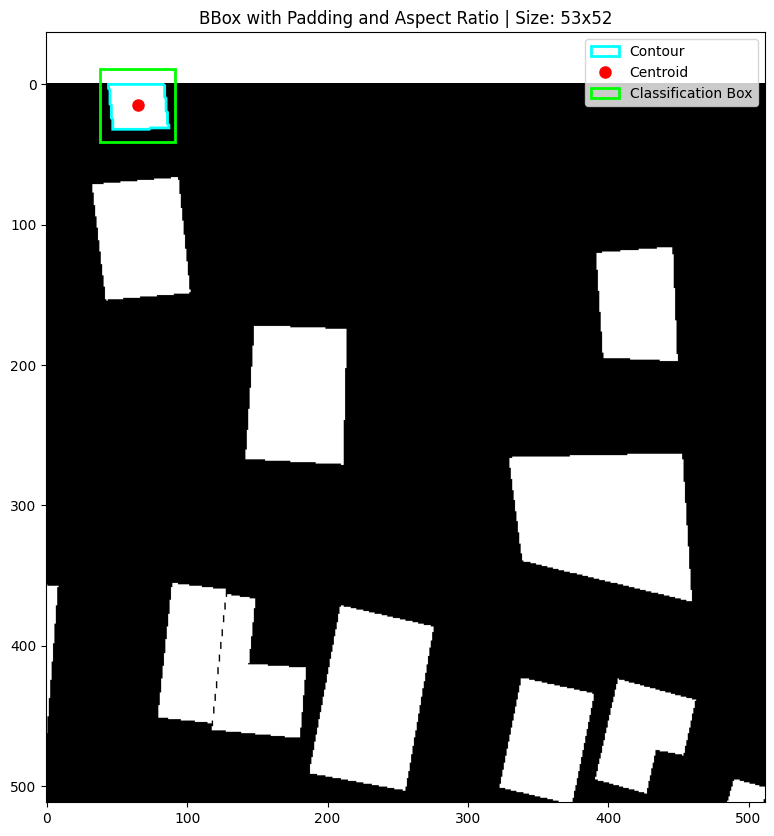

In [ ]:


def plot_classification_results(image, contour, centroid, bbox):
    """
    Visualizes the image, its contour, centroid, and the calculated BBox.
    bbox: (x1, y1, x2, y2)
    """
    fig, ax = plt.subplots(1, figsize=(10, 10))
    
    # Display the image
    ax.imshow(image, cmap='gray')
    
    # 1. Plot the Contour
    # Contours are (N, 1, 2) arrays, we squeeze to (N, 2)
    poly_pts = contour.squeeze()
    ax.add_patch(patches.Polygon(poly_pts, closed=True, fill=False, edgecolor='cyan', linewidth=2, label='Contour'))
    
    # 2. Plot the Centroid
    ax.plot(centroid[0], centroid[1], 'ro', markersize=8, label='Centroid')
    
    # 3. Plot the Bounding Box
    x1, y1, x2, y2 = bbox
    width = x2 - x1
    height = y2 - y1
    rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='lime', facecolor='none', label='Classification Box')
    ax.add_patch(rect)
    
    plt.legend(loc='upper right')
    plt.title(f"BBox with Padding and Aspect Ratio | Size: {width}x{height}")
    plt.show()

# --- Example Usage inside your loop ---
x1, y1, x2, y2 = get_classification_bbox((cX, cY), w, h, padding=0.2, aspect_ratio=1.0)
plot_classification_results(imgg, cnt, (cX, cY), (x1, y1, x2, y2))

In [207]:

## Higher the epsilon, higher are the threshold of the Douglas-Peucked algorithm. Which means far and more rectangular than a smaller episolon
epsilon = cv2.arcLength(cnt, True)*0.002 ## 0.1 of the arclength (perimeter)

## In case of very complexed geometries. 
approx =  cv2.approxPolyDP(cnt, epsilon, True)

print(len(cnt), len(approx))
print(epsilon)
print(approx)


8 8
0.34965685415267944
[[[ 64   0]]

 [[ 64   1]]

 [[ 65   2]]

 [[ 65  17]]

 [[135  17]]

 [[135   8]]

 [[134   7]]

 [[134   0]]]


### Classification

In [5]:
from src.utils import labelling
importlib.reload(labelling)

<module 'src.utils.labelling' from '/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dev/src/utils/labelling.py'>

In [6]:
from src.utils.labelling import create_labels_yolov11_classification

In [26]:
output_folder = os.path.join(config['datasets']['root_folder'],config['datasets']['name_labels_folder'])
print(f"The files are being saved at: {output_folder}")


## Create the labels for the image
list_contours_lesser_thre_area = create_labels_yolov11_classification(
                                                list_bitmap,
                                                output_folder = output_folder
                                                )

The files are being saved at: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels
The files will be written at: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels
Processed: tile-199113-295989-19.txt | 0.55%
Processed: tile-199109-295992-19.txt | 1.10%
Processed: tile-199110-295968-19.txt | 1.66%
Processed: tile-199110-295992-19.txt | 2.21%
Processed: tile-199107-295971-19.txt | 2.76%
Processed: tile-199108-295986-19.txt | 3.31%
Processed: tile-199115-295991-19.txt | 3.87%
Processed: tile-199107-295977-19.txt | 4.42%
Processed: tile-199105-295978-19.txt | 4.97%
Processed: tile-199103-295968-19.txt | 5.52%
Processed: tile-199109-295989-19.txt | 6.08%
Processed: tile-199107-295989-19.txt | 6.63%
Processed: tile-199110-295990-19.txt | 7.18%
Processed: tile-199103-295977-19.txt | 7.73%
Processed: tile-199106-295982-19.txt | 8.29%
Processed: tile-199108-295982-19.txt | 8.84%
Processed: t

In [27]:
list_contours_lesser_thre_area

[('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199110-295968-19.png',
  0),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199109-295995-19.png',
  7),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199110-295969-19.png',
  3),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199108-295975-19.png',
  4),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199107-295998-19.png',
  1),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199110-295986-19.png',
  2),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199105-295969-19.png',
  0),
 ('/home/cama

In [7]:
list_labels = glob.glob(os.path.join(
    config["datasets"]["root_folder"],
    config["datasets"]["name_labels_folder"],
    "*.txt"
))

In [8]:
with open(list_labels[random.randint(0,len(list_labels))], 'r') as f:
    print(f.name)
    print(f.read())

/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels/tile-199108-295997-19.txt
0 0.81142662 0.94292152 0.29003906 0.29003906
0 0.52482502 0.87943390 0.19980469 0.19980469
0 0.33975747 0.83646422 0.21699219 0.21699219
0 0.03747804 0.64236022 0.12675781 0.12675781
0 0.16653129 0.45216361 0.16113281 0.16113281
0 0.34331384 0.31460048 0.17832031 0.17832031
0 0.55419955 0.27522743 0.13964844 0.13964844
0 0.90335931 0.24992921 0.12890625 0.12890625
0 0.32254380 0.22142197 0.13320313 0.13320313



In [9]:
def plot_yolo_bbox(image_path, label_path):
    # 1. Load the image to get dimensions
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert for matplotlib
    img_h, img_w, _ = img.shape

    # 2. Read the YOLO label file
    with open(label_path, 'r') as f:
        lines = f.readlines()

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)

    for line in lines:
        # Parse: class x_center y_center width height
        parts = line.split()
        cls, x_c, y_c, w, h = map(float, parts)

        # 3. De-normalize coordinates
        # YOLO center-x * image-width = pixel center-x
        abs_x_c = x_c * img_w
        abs_y_c = y_c * img_h
        abs_w = w * img_w
        abs_h = h * img_h

        # 4. Calculate Top-Left corner for matplotlib Rectangle
        x1 = abs_x_c - (abs_w / 2)
        y1 = abs_y_c - (abs_h / 2)

        # 5. Create and add the patch
        rect = patches.Rectangle(
            (x1, y1), abs_w, abs_h, 
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Optional: Add label text
        plt.text(x1, y1-5, f"Class {int(cls)}", color='lime', weight='bold')

    plt.title(f"Visualizing: {label_path.split('/')[-1]}")
    plt.axis('off')
    plt.show()


In [10]:

## plot the pairwise 
# Create lookup dictionary
bitmap_dict = {Path(f).stem: f for f in list_labels}

# Find matches
matching_pairs = [(tile, bitmap_dict[Path(tile).stem]) 
                  for tile in list_files 
                  if Path(tile).stem in bitmap_dict]

In [11]:
matching_pairs[0][0]

'/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199108-295990-19.tif'

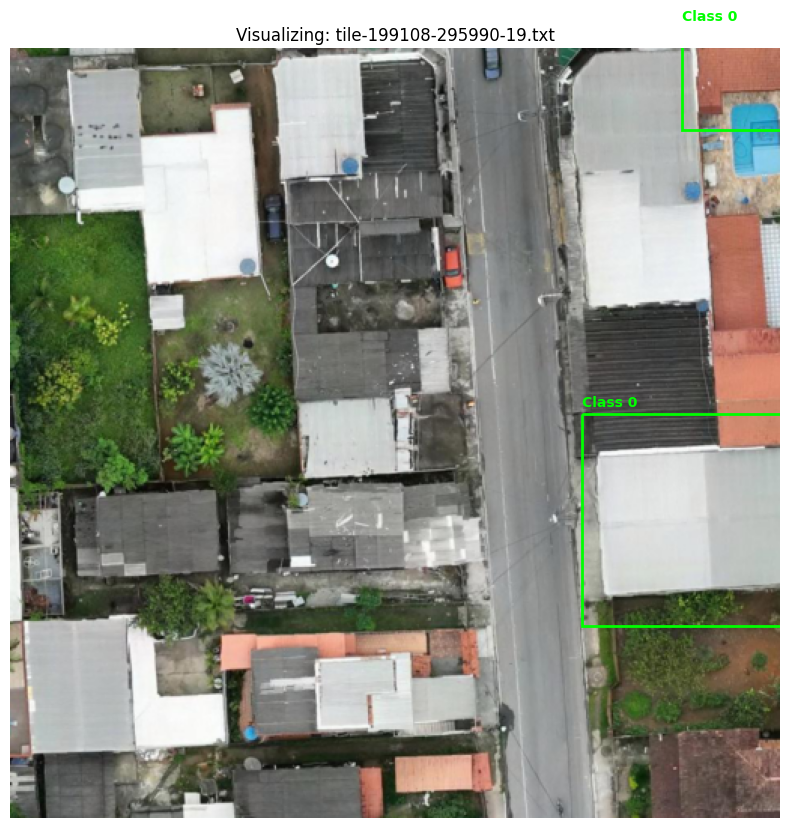

In [14]:
plot_yolo_bbox(matching_pairs[0][0] , matching_pairs[0][1])

# STOP HERE

### Segmentation Label

it creates the folder labels_segmentation. 

In [116]:
from src.utils.labelling import create_labels_yolov11_segmentation

In [ ]:
output_folder = os.path.join(config['datasets']['root_folder'],
                              config['datasets']['name_labels_segmentation'])
print(f"The files are being saved at : {output_folder}")

list_issues_ = create_labels_yolov11_segmentation(list_bitmap,
                                                   output_folder,
                                                     percent_epsilon=0.001)

The files are being saved at : /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation
The files are be written at: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation
Processed: tile-199113-295989-19.txt | 0.55%
Processed: tile-199109-295992-19.txt | 1.10%
Processed: tile-199110-295968-19.txt | 1.66%
Processed: tile-199110-295992-19.txt | 2.21%
Processed: tile-199107-295971-19.txt | 2.76%
Processed: tile-199108-295986-19.txt | 3.31%
Processed: tile-199115-295991-19.txt | 3.87%
Processed: tile-199107-295977-19.txt | 4.42%
Processed: tile-199105-295978-19.txt | 4.97%
Processed: tile-199103-295968-19.txt | 5.52%
Processed: tile-199109-295989-19.txt | 6.08%
Processed: tile-199107-295989-19.txt | 6.63%
Processed: tile-199110-295990-19.txt | 7.18%
Processed: tile-199103-295977-19.txt | 7.73%
Processed: tile-199106-295982-19.txt | 8.29%
Processed: tile-199108-295982-1

In [163]:
list_issues_

[('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199110-295968-19.png',
  0),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199109-295995-19.png',
  7),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199110-295969-19.png',
  3),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199108-295975-19.png',
  4),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199107-295998-19.png',
  1),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199110-295986-19.png',
  2),
 ('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/bitmap/tile-199105-295969-19.png',
  0),
 ('/home/cama

Plotting 1 pairs in 1 rows x 2 pairs per row


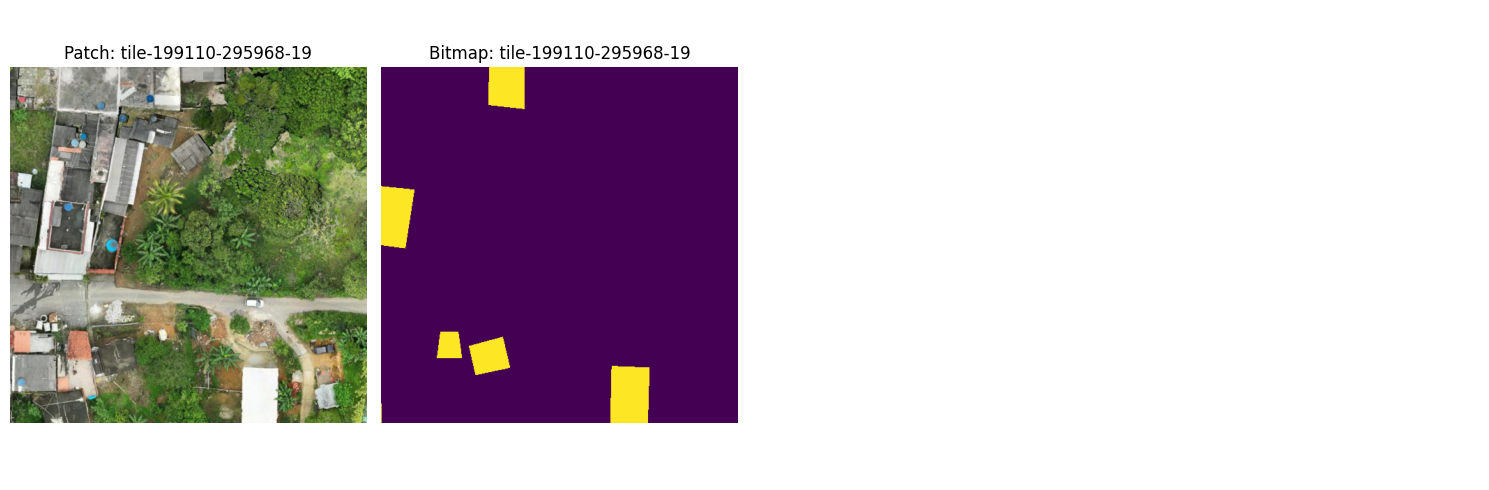

In [ ]:
plot_pairwise(
                [(str(Path(list_issues_[0][0]).parent.parent.joinpath("tiles").joinpath(str(Path(list_issues_[0][0]).stem)+".tif")),
                list_issues_[0][0])],
              1
              )

In [164]:
output_folder = os.path.join(config['datasets']['root_folder'], config['datasets']['name_labels_segmentation'])
print(f"The files are being saved at : {output_folder}")

list_issues_ = create_labels_yolov11_segmentation(list_bitmap, output_folder, percent_epsilon=0.001)

The files are being saved at : /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation
The files are be written at: /home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation
Processed: tile-199113-295989-19.txt | 0.55%
Processed: tile-199109-295992-19.txt | 1.10%
Processed: tile-199110-295968-19.txt | 1.66%
Processed: tile-199110-295992-19.txt | 2.21%
Processed: tile-199107-295971-19.txt | 2.76%
Processed: tile-199108-295986-19.txt | 3.31%
Processed: tile-199115-295991-19.txt | 3.87%
Processed: tile-199107-295977-19.txt | 4.42%
Processed: tile-199105-295978-19.txt | 4.97%
Processed: tile-199103-295968-19.txt | 5.52%
Processed: tile-199109-295989-19.txt | 6.08%
Processed: tile-199107-295989-19.txt | 6.63%
Processed: tile-199110-295990-19.txt | 7.18%
Processed: tile-199103-295977-19.txt | 7.73%
Processed: tile-199106-295982-19.txt | 8.29%
Processed: tile-199108-295982-1

In [165]:
list_labels_seg = glob.glob(os.path.join(
    config["datasets"]["root_folder"],
    config["datasets"]["name_labels_segmentation"],
    "*.txt"
))

with open(list_labels_seg[random.randint(0,len(list_labels))], 'r') as f:
    print(f.name)
    print(f.read())

/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation/tile-199113-295992-19.txt
0 0.60156250 0.47265625 0.59960938 0.47265625 0.59765625 0.47460938 0.59570312 0.47460938 0.59375000 0.47656250 0.59179688 0.47656250 0.58593750 0.48046875 0.58203125 0.48046875 0.58007812 0.48242188 0.57812500 0.48242188 0.57617188 0.48437500 0.57421875 0.48437500 0.56835938 0.48828125 0.56445312 0.48828125 0.56250000 0.49023438 0.56054688 0.49023438 0.55859375 0.49218750 0.55664062 0.49218750 0.55078125 0.49609375 0.54687500 0.49609375 0.54492188 0.49804688 0.54296875 0.49804688 0.54101562 0.50000000 0.53906250 0.50000000 0.53320312 0.50390625 0.52929688 0.50390625 0.52734375 0.50585938 0.52539062 0.50585938 0.52343750 0.50781250 0.52148438 0.50781250 0.51562500 0.51171875 0.51171875 0.51171875 0.50976562 0.51367188 0.50976562 0.51562500 0.51367188 0.52148438 0.51367188 0.52539062 0.51562500 0.52734375 0.51562500 0.52929688 0.51757812 0.531250

In [170]:
Path(list_labels_seg[0]).parent.joinpath(str(Path(list_issues_[0][0]).stem)+".txt")

PosixPath('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation/tile-199110-295968-19.txt')

In [173]:
## path with issues
paaath = Path(list_labels_seg[0]).parent.joinpath(str(Path(list_issues_[0][0]).stem)+".txt")
with open(paaath, 'r') as f:
    print(f.name)
    print(f.read())

/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation/tile-199110-295968-19.txt
0 0.00000000 0.94531250 0.00000000 0.99804688
0 0.64648438 0.83984375 0.64648438 0.84765625 0.64453125 0.84960938 0.64453125 0.92773438 0.64257812 0.92968750 0.64257812 0.99804688 0.74609375 0.99804688 0.74609375 0.96289062 0.74804688 0.96093750 0.74804688 0.89648438 0.75000000 0.89453125 0.75000000 0.84375000 0.71093750 0.84375000 0.70898438 0.84179688 0.66406250 0.84179688 0.66210938 0.83984375
0 0.33984375 0.75781250 0.33789062 0.75976562 0.33203125 0.75976562 0.33007812 0.76171875 0.32617188 0.76171875 0.32421875 0.76367188 0.31835938 0.76367188 0.31640625 0.76562500 0.31054688 0.76562500 0.30859375 0.76757812 0.30273438 0.76757812 0.30078125 0.76953125 0.29687500 0.76953125 0.29492188 0.77148438 0.28906250 0.77148438 0.28710938 0.77343750 0.28125000 0.77343750 0.27929688 0.77539062 0.27539062 0.77539062 0.27343750 0.77734375 0.26757812 0.77

### Plot Label - Check

In [174]:
from src.utils.util import compose_zip_folder
from src.utils.plots import plot_segmentation_label
from src.utils.labelling import read_segmentation_label

In [175]:
matching_pairs =compose_zip_folder(list_folder1= list_labels_seg,  ## segmentation labels
                                   list_folder2=list_files) ## original RGB

In [176]:
matching_pairs[0]

('/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/tiles/tile-199108-295990-19.tif',
 '/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels_segmentation/tile-199108-295990-19.txt')

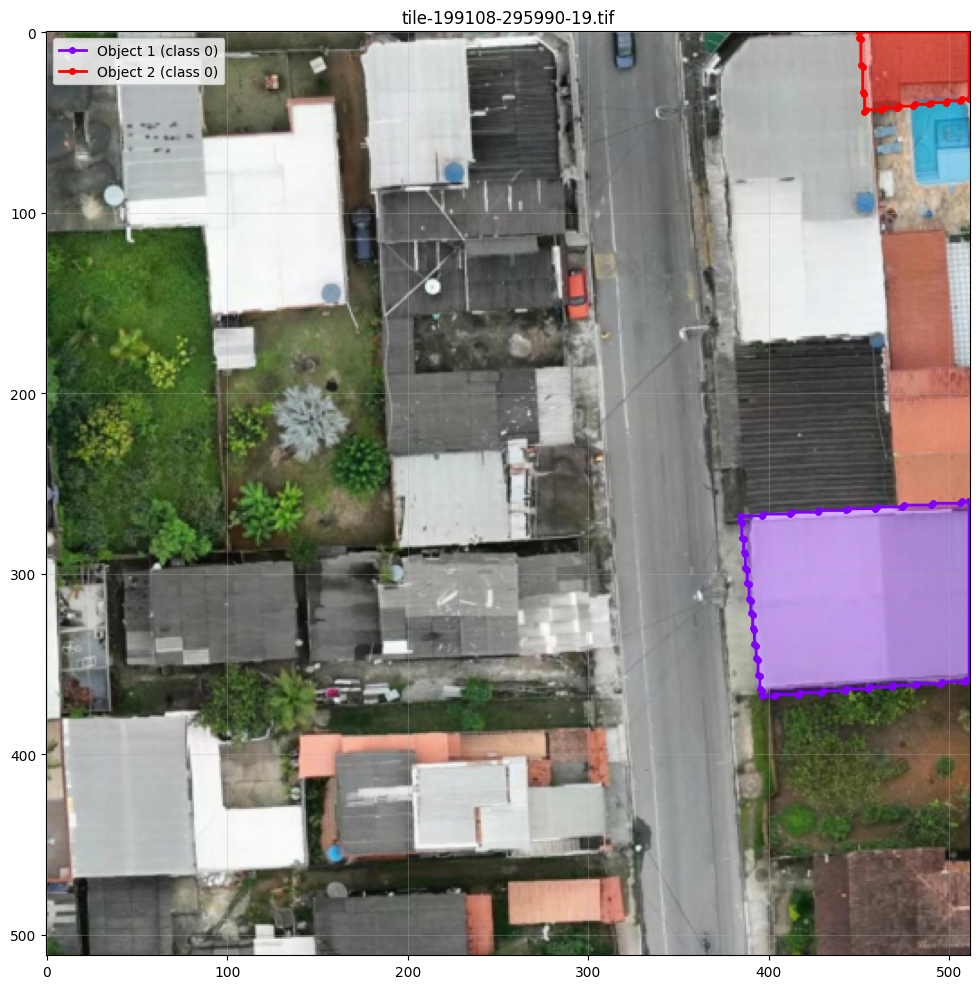

In [178]:
plot_segmentation_label(txt_path = matching_pairs[0][1], image_path=matching_pairs[0][0])

In [181]:
list_labels

['/home/camarada/Documents/CDE/3-semester/DeepLearning/building-footprint/dataset/improved_dataset/labels/tile-199113-295989-19.txt']

In [180]:
read_segmentation_label(list_labels[0])

NameError: name 'np' is not defined

In [207]:
zip_labels_classification = compose_zip_folder(list_labels, list_files)

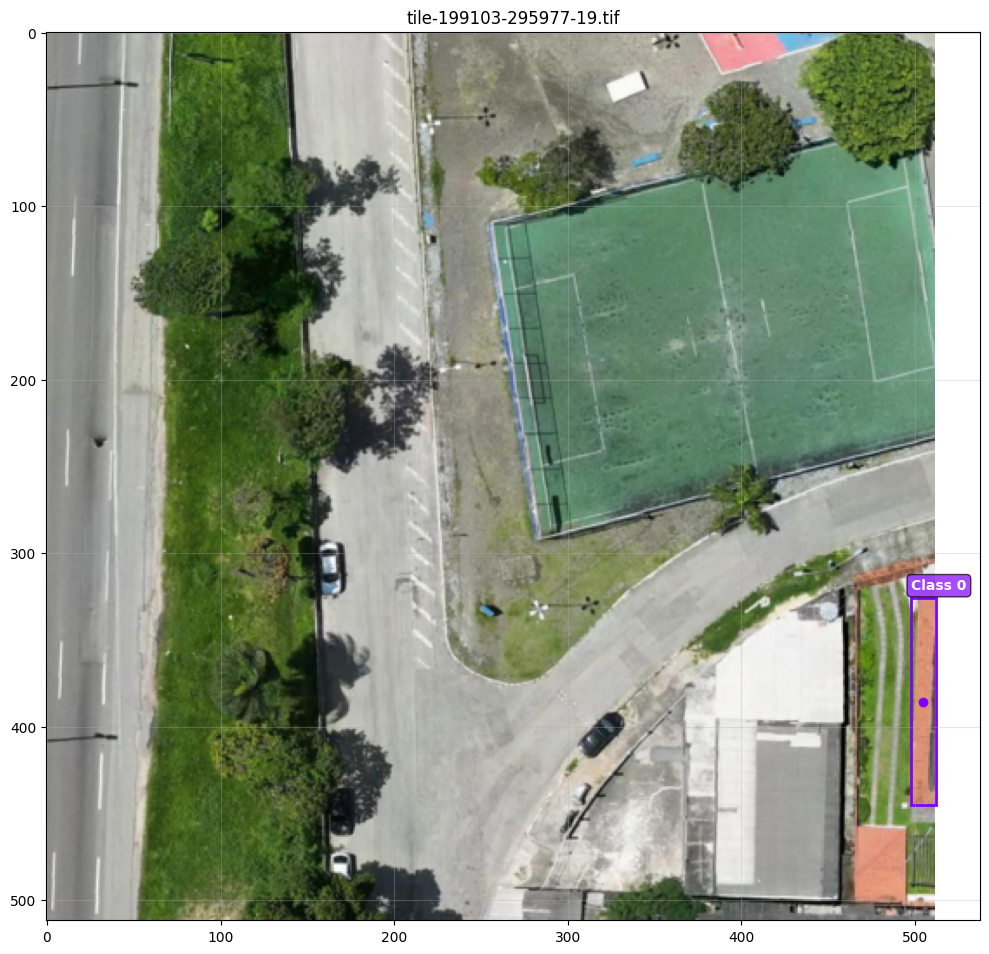

In [213]:
plot_yolo_detection(zip_labels_classification[0][1], zip_labels_classification[0][0])

In [203]:
def read_yolo_detection_label(txt_path):
    """
    Read a YOLO object detection label file (bounding boxes).
    
    Format: class_id x_center y_center width height
    All coordinates are normalized (0-1).
    
    Args:
        txt_path: Path to the .txt label file
        
    Returns:
        list of dictionaries, each containing:
            - 'class_id': int
            - 'x_center': float (normalized)
            - 'y_center': float (normalized)
            - 'width': float (normalized)
            - 'height': float (normalized)
    """
    boxes = []
    
    with open(txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:  # Must have exactly 5 values
                continue
            
            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
            
            boxes.append({
                'class_id': class_id,
                'x_center': x_center,
                'y_center': y_center,
                'width': width,
                'height': height
            })
    
    return boxes